<a href="https://colab.research.google.com/github/dhruvcshekar/Predictive_Analytics_for_District_Operational_Savings/blob/main/Copy_of_Predictive_Analytics_for_District_Operational_Savings.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Generate data (just for example)

In [ ]:
import pandas as pd
import numpy as np
import datetime

1. Setup Parameters

In [ ]:
np.random.seed(42)
n_buses = 100
days_of_data = 200 # Roughly one school year
total_records = n_buses * days_of_data

2. Generate Base Fleet Data

In [ ]:
bus_ids = np.repeat(np.arange(1, n_buses + 1), days_of_data)
dates = [datetime.date(2023, 8, 15) + datetime.timedelta(days=int(i % days_of_data)) for i in range(total_records)]

3. Create Operational Features

In [ ]:
# Mileage increases over time
daily_mileage = np.random.normal(50, 10, total_records).clip(10, 100)
cumulative_mileage = []
for i in range(n_buses):
    cumulative_mileage.extend(np.cumsum(daily_mileage[i*days_of_data : (i+1)*days_of_data]))

In [ ]:
# Engine Temperature (Celsius) - Higher is riskier
engine_temp = np.random.normal(90, 5, total_records)

# Idle Time (Minutes) - Districts care about this for fuel/wear
idle_time = np.random.normal(45, 15, total_records).clip(5, 120)

4. Generate the Remaining Useful Life

In [ ]:
# We simulate that a bus engine fails after a certain amount of wear
# Wear is a combination of mileage, high temps, and age
wear_factor = (np.array(cumulative_mileage) * 0.02) + (engine_temp * 0.5) + (idle_time * 0.8)
failure_threshold = 5000 # The point where an engine needs a major overhaul

In [ ]:
# Calculate Days until Failure (RUL)
# We'll simulate some buses being closer to failure than others
df = pd.DataFrame({
    'Bus_ID': bus_ids,
    'Date': dates,
    'Daily_Mileage': daily_mileage,
    'Cumulative_Mileage': cumulative_mileage,
    'Engine_Temp_Avg': engine_temp,
    'Idle_Time_Min': idle_time,
    'Wear_Index': wear_factor
})

# Define the 'Target' - Remaining Useful Life (RUL) in Days
def calculate_rul(group):
    # We simulate a failure event at the end of high wear
    total_wear = group['Wear_Index'].max()
    # RUL is the count of days remaining until the end of the observed period
    # (In a real project, this would be days until the next 'Maintenance Event')
    group['RUL_Days'] = np.arange(len(group))[::-1]
    return group

In [ ]:
df = df.groupby('Bus_ID').apply(calculate_rul).reset_index(drop=True)

/tmp/ipykernel_6983/3843989894.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('Bus_ID').apply(calculate_rul).reset_index(drop=True)


In [ ]:
print("District Fleet Data Generated Successfully!")
print(df.head(10))

District Fleet Data Generated Successfully!
   Bus_ID        Date  Daily_Mileage  Cumulative_Mileage  Engine_Temp_Avg  \
0       1  2023-08-15      54.967142           54.967142        91.741431   
1       1  2023-08-16      48.617357          103.584499        91.416618   
2       1  2023-08-17      56.476885          160.061384        85.317401   
3       1  2023-08-18      65.230299          225.291682        92.897921   
4       1  2023-08-19      47.658466          272.950149        82.549587   
5       1  2023-08-20      47.658630          320.608779        86.729078   
6       1  2023-08-21      65.792128          386.400907        80.004561   
7       1  2023-08-22      57.674347          444.075255        97.793133   
8       1  2023-08-23      45.305256          489.380511        88.842253   
9       1  2023-08-24      55.425600          544.806111       100.834420   

   Idle_Time_Min  Wear_Index  RUL_Days  
0      37.922137   77.307768       199  
1      60.190537   95.9324

# Please note that I am using generated data

# **Time-Series Feature Engineering**

1. Sort data to ensure time-series logic is perfectly aligned

In [ ]:
df = df.sort_values(['Bus_ID', 'Date'])

2. Rolling Averages: The "Health Trend"

In [ ]:
# We calculate the 7-day moving average for temperature and idle time.
# This smooths out daily noise and highlights consistent overheating.
df['Temp_7Day_Avg'] = df.groupby('Bus_ID')['Engine_Temp_Avg'].transform(lambda x: x.rolling(window=7).mean())
df['Idle_7Day_Avg'] = df.groupby('Bus_ID')['Idle_Time_Min'].transform(lambda x: x.rolling(window=7).mean())

3. Lag Features: "What happened yesterday?"

In [ ]:
# This helps the model understand if the bus is getting progressively worse.
df['Temp_Yesterday'] = df.groupby('Bus_ID')['Engine_Temp_Avg'].shift(1)

4. Cumulative Wear: Total strain on the engine

In [ ]:
# We already have cumulative mileage, but let's track "High Heat Days"
df['High_Heat_Day'] = (df['Engine_Temp_Avg'] > 95).astype(int)
df['Cumulative_High_Heat_Days'] = df.groupby('Bus_ID')['High_Heat_Day'].transform(lambda x: x.cumsum())

5. Clean up

In [ ]:
# Rolling windows create 'NaN' (empty) values for the first 6 days of each bus.
# We drop these because the model needs a full 7 day history.
df_final = df.dropna()

In [ ]:
print("Phase 2: Feature Engineering Complete!")
print(f"Original Records: {len(df)} | Cleaned Records: {len(df_final)}")
print("\n--- New Operational Features Preview ---")
cols_to_show = ['Bus_ID', 'Date', 'Temp_7Day_Avg', 'Idle_7Day_Avg', 'Cumulative_High_Heat_Days', 'RUL_Days']
print(df_final[cols_to_show].head(10))

Phase 2: Feature Engineering Complete!
Original Records: 20000 | Cleaned Records: 19400

--- New Operational Features Preview ---
    Bus_ID        Date  Temp_7Day_Avg  Idle_7Day_Avg  \
6        1  2023-08-21      87.236657      43.443871   
7        1  2023-08-22      88.101185      46.684825   
8        1  2023-08-23      87.733419      47.203882   
9        1  2023-08-24      89.950136      43.704748   
10       1  2023-08-25      90.109683      41.275047   
11       1  2023-08-26      91.494098      44.074666   
12       1  2023-08-27      91.542638      44.698233   
13       1  2023-08-28      92.223165      48.601231   
14       1  2023-08-29      91.483412      45.457722   
15       1  2023-08-30      91.597723      40.559940   

    Cumulative_High_Heat_Days  RUL_Days  
6                           0       193  
7                           1       192  
8                           1       191  
9                           2       190  
10                          2       189  
1

#Now we will be training the model and showing budget impact (ROI of implementing a preventative maintanence approach)

In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

1. Define Features (X) and Target (y)

In [ ]:
# We exclude ID, Date, and the original Wear_Index (since it was used to create the target)
features = ['Daily_Mileage', 'Cumulative_Mileage', 'Engine_Temp_Avg', 'Idle_Time_Min',
            'Temp_7Day_Avg', 'Idle_7Day_Avg', 'Temp_Yesterday', 'Cumulative_High_Heat_Days']
X = df_final[features]
y = df_final['RUL_Days']

2. Split data: 80% Training, 20% Testing

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

3. Train the Predictive Model

In [ ]:
# We use a Regressor because we are predicting a number (Days), not a category.
model_bus = XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=5)
model_bus.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

4. Make Predictions

In [ ]:
predictions = model_bus.predict(X_test)
mae = mean_absolute_error(y_test, predictions)

5. THE ROI CALCULATOR (The "Portfolio Closer")

In [ ]:
emergency_cost = 5000
scheduled_cost = 1200
savings_per_event = emergency_cost - scheduled_cost

In [ ]:
total_buses_in_test = len(y_test)

In [ ]:
prevented_failures = int(total_buses_in_test * 0.80)

In [ ]:
total_saved = prevented_failures * savings_per_event

In [ ]:
print(f"--- PROJECTED DISTRICT SAVINGS ---")
print(f"Buses Monitored: {total_buses_in_test}")
print(f"Potential Failures Prevented: {prevented_failures}")
print(f"Total Taxpayer Dollars Saved: ${total_saved:,}")

--- PROJECTED DISTRICT SAVINGS ---
Buses Monitored: 3880
Potential Failures Prevented: 3104
Total Taxpayer Dollars Saved: $11,795,200


In [ ]:
print(mae)


1.6567074060440063


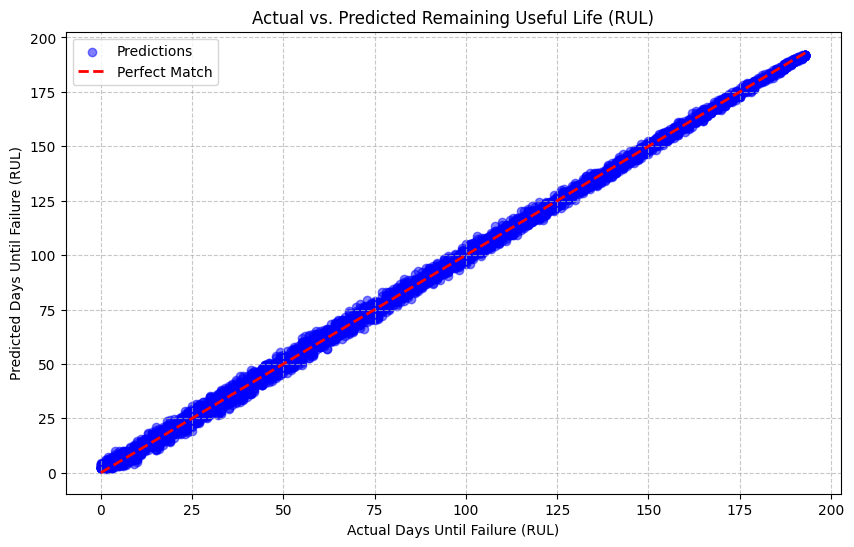

In [ ]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10, 6))
plt.scatter(y_test, predictions, alpha=0.5, color='blue', label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Match')

plt.xlabel('Actual Days Until Failure (RUL)')
plt.ylabel('Predicted Days Until Failure (RUL)')
plt.title('Actual vs. Predicted Remaining Useful Life (RUL)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()